# So sánh Cung–Cầu · Contact rate Explicit · CVR (positive)

Bổ sung cho [`eda_listing_snapshot_temporal_deep.ipynb`](eda_listing_snapshot_temporal_deep.ipynb) — **tổng theo 5 category**, không trend thời gian.

| Khái niệm | Cột / công thức | Nguồn |
|-----------|-----------------|--------|
| **Cung (supply)** | `n_listings` = tin distinct trong `snap_enriched` | Không lọc `posted_cohort` · join `dim_listing` dedup |
| **Cầu — explicit** | `n_explicit_events` (4 loại, **login + non-login**) | `fact_user_events` |
| **Cầu — positive** | `n_positive_events` (5 loại README, **login + non-login**) | `fact_user_events` |
| **Contact rate Explicit** | `explicit_per_1k_listings` = 1000 × explicit / tin | Mẫu số = supply |
| **CVR (positive)** | `positive_per_1k_listings` = 1000 × positive / tin | Mục tiêu dự đoán README |
| **% trên tổng VN** | `pct_listings`, `pct_explicit_events`, `pct_positive_events` | Mỗi category ÷ tổng 5 category (weighted) |
| **Ex-HCM** | Bảng sau khi trừ TP.HCM | `01c_ex_hcm_category_share_pct.csv` — `pct_*` trên tổng RoVN |
| **% TP.HCM** | `pct_*_hcm` theo category | Cung & cầu: `dim_snap.city_name` |

**Lọc:** category 1010–1050 · `ad_type` sell/let · **không** `posted_cohort` · events `date` ∈ cửa sổ snapshot · cầu **login + non-login** · join `dim_listing` dedup qua `item_id`.

> **Không nhầm** với `contact_rate_pct` snapshot (= Σcontacts_24h ÷ Σviews_24h). BCG region dùng login-only — khác định nghĩa cầu ở đây.


In [101]:
%matplotlib inline
import os
os.environ["MPL_SHOW"] = "1"

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

import importlib
import eda_listing_snapshot_temporal_deep as snap
importlib.reload(snap)

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_ROOT = snap.DATA_ROOT
OUT_DIR = DATA_ROOT / "outputs" / "eda_supply_demand_cvr"
OUT_DIR.mkdir(parents=True, exist_ok=True)

POSITIVE_TYPES = (
    "view_phone",
    "contact_chat",
    "contact_zalo",
    "contact_sms",
    "other_interaction",
)
POSITIVE_SQL = ", ".join(repr(x) for x in POSITIVE_TYPES)
CAT_IN = ", ".join(str(c) for c in snap.CATEGORIES)

snap.configure_matplotlib(notebook=True)
snap.check_data_dirs()
con = snap.connect_duckdb()
snap.ensure_caches(con)
snap.register_snap_view(con)

def sql_snap_dim() -> str:
    """CTE snap_window (cho events) + dim_snap (dim_listing dedup, không posted_cohort)."""
    return f"""
    snap_window AS (
        SELECT MIN(date) AS eda_min, MAX(date) AS eda_max FROM snap_enriched
    ),
    dim_snap AS (
        SELECT item_id, category, ad_type, city_name
        FROM (
            SELECT
                CAST(item_id AS VARCHAR) AS item_id,
                category,
                ad_type,
                TRIM(CAST(city_name AS VARCHAR)) AS city_name,
                ROW_NUMBER() OVER (
                    PARTITION BY item_id ORDER BY posted_date DESC NULLS LAST
                ) AS rn
            FROM read_parquet('{snap.DIM_GLOB}') d
            WHERE d.category IN ({CAT_IN})
              AND d.ad_type IN ('let', 'sell')
        )
        WHERE rn = 1
    )"""


_eda = con.execute(
    "SELECT MIN(date) AS eda_min, MAX(date) AS eda_max FROM snap_enriched"
).fetchone()
_n_dim = con.execute(f"""
    WITH {sql_snap_dim()}
    SELECT COUNT(*)::BIGINT FROM dim_snap
""").fetchone()[0]
print(f"EDA window: {_eda[0]} → {_eda[1]} · dim_snap n={_n_dim:,}")

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110


def show_and_save(name: str, **kwargs):
    path = OUT_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight", **kwargs)
    plt.show()
    print("Saved", path)


def is_hcmc_sql(col: str) -> str:
    """Điều kiện TP.HCM — khớp Thinh_Analyze/run_region_revenue_bcg.is_hcmc_name."""
    c = (
        f"lower(replace(replace(trim(cast({col} AS VARCHAR)), 'tp.', 'tp'), '  ', ' '))"
    )
    return (
        f"({c} LIKE '%hồ chí minh%' OR {c} LIKE '%ho chi minh%' "
        f"OR {c} IN ('tp hồ chí minh', 'tp ho chi minh', 'hồ chí minh'))"
    )


print("DATA_ROOT =", DATA_ROOT)
print(snap.DATA_RANGE)
print("Cache OK:", snap.SNAP_CACHE.exists())

EDA window: 2025-11-09 → 2026-04-09 · dim_snap n=52,957
DATA_ROOT = /Users/dothinh_3112/Downloads/Datathon_Data
fact_listing_snapshot · 2025-11-09 → 2026-04-09 · full data
Cache OK: True


In [102]:
df = con.execute(f"""
WITH {sql_snap_dim()},
supply AS (
    SELECT
        d.category,
        COUNT(DISTINCT s.item_id)::BIGINT AS n_listings,
        COUNT(*)::BIGINT AS n_listing_days
    FROM snap_enriched s
    INNER JOIN dim_snap d ON s.item_id = d.item_id
    GROUP BY 1
),
demand AS (
    SELECT
        d.category,
        SUM(CASE WHEN e.event_type IN ({snap.EXPLICIT_SQL}) THEN 1 ELSE 0 END)::BIGINT
            AS n_explicit_events,
        SUM(CASE WHEN e.event_type IN ({POSITIVE_SQL}) THEN 1 ELSE 0 END)::BIGINT
            AS n_positive_events
    FROM read_parquet('{snap.EVENTS_GLOB}') e
    INNER JOIN dim_snap d ON CAST(e.item_id AS VARCHAR) = d.item_id
    CROSS JOIN snap_window w
    WHERE e.date BETWEEN w.eda_min AND w.eda_max
    GROUP BY 1
)
SELECT
    s.category,
    s.n_listings,
    s.n_listing_days,
    COALESCE(d.n_explicit_events, 0)::BIGINT AS n_explicit_events,
    COALESCE(d.n_positive_events, 0)::BIGINT AS n_positive_events,
    ROUND(1000.0 * COALESCE(d.n_explicit_events, 0) / NULLIF(s.n_listings, 0), 2)
        AS explicit_per_1k_listings,
    ROUND(1000.0 * COALESCE(d.n_positive_events, 0) / NULLIF(s.n_listings, 0), 2)
        AS positive_per_1k_listings,
    ROUND(100.0 * COALESCE(d.n_explicit_events, 0)
          / NULLIF(COALESCE(d.n_positive_events, 0), 0), 2) AS demand_explicit_share_pct
FROM supply s
LEFT JOIN demand d ON s.category = d.category
ORDER BY s.category
""").df()

df["category"] = df["category"].astype(int)
df["category_label"] = df["category"].map(snap.CAT_META)
df = df.set_index("category").reindex(list(snap.CATEGORIES)).reset_index()

_tot_listings = float(df["n_listings"].sum())
_tot_explicit = float(df["n_explicit_events"].sum())
_tot_positive = float(df["n_positive_events"].sum())
df["pct_listings"] = (df["n_listings"] / _tot_listings * 100.0).round(2)
df["pct_explicit_events"] = (df["n_explicit_events"] / _tot_explicit * 100.0).round(2)
df["pct_positive_events"] = (df["n_positive_events"] / _tot_positive * 100.0).round(2)

total = pd.DataFrame([{
    "category": 0,
    "category_label": "Tổng (weighted)",
    "n_listings": int(df["n_listings"].sum()),
    "n_listing_days": int(df["n_listing_days"].sum()),
    "n_explicit_events": int(df["n_explicit_events"].sum()),
    "n_positive_events": int(df["n_positive_events"].sum()),
    "explicit_per_1k_listings": round(
        1000.0 * df["n_explicit_events"].sum() / df["n_listings"].sum(), 2
    ),
    "positive_per_1k_listings": round(
        1000.0 * df["n_positive_events"].sum() / df["n_listings"].sum(), 2
    ),
    "demand_explicit_share_pct": round(
        100.0 * df["n_explicit_events"].sum() / df["n_positive_events"].sum(), 2
    ),
    "pct_listings": 100.0,
    "pct_explicit_events": 100.0,
    "pct_positive_events": 100.0,
}])

csv_path = OUT_DIR / "01_category_supply_demand_cvr.csv"
df.to_csv(csv_path, index=False)
print("Saved", csv_path)

assert (df["positive_per_1k_listings"] >= df["explicit_per_1k_listings"]).all()
assert (df["n_positive_events"] >= df["n_explicit_events"]).all()
print("Sanity OK: positive >= explicit per category")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_supply_demand_cvr/01_category_supply_demand_cvr.csv
Sanity OK: positive >= explicit per category


## % TP. Hồ Chí Minh — ảnh hưởng lên tổng từng category

`pct_*_hcm` = khối lượng HCM ÷ tổng category (cung từ `dim_listing`, cầu từ `events.city_name`).

In [103]:
hcm_cond_d = is_hcmc_sql("d.city_name")

df_hcm = con.execute(f"""
WITH {sql_snap_dim()},
supply_geo AS (
    SELECT
        d.category,
        COUNT(DISTINCT CASE WHEN {hcm_cond_d} THEN s.item_id END)::BIGINT AS n_listings_hcm,
        COUNT(DISTINCT s.item_id)::BIGINT AS n_listings_all
    FROM snap_enriched s
    INNER JOIN dim_snap d ON s.item_id = d.item_id
    GROUP BY 1
),
demand_geo AS (
    SELECT
        d.category,
        SUM(CASE WHEN {hcm_cond_d} AND e.event_type IN ({snap.EXPLICIT_SQL}) THEN 1 ELSE 0 END)::BIGINT
            AS n_explicit_hcm,
        SUM(CASE WHEN e.event_type IN ({snap.EXPLICIT_SQL}) THEN 1 ELSE 0 END)::BIGINT AS n_explicit_all,
        SUM(CASE WHEN {hcm_cond_d} AND e.event_type IN ({POSITIVE_SQL}) THEN 1 ELSE 0 END)::BIGINT
            AS n_positive_hcm,
        SUM(CASE WHEN e.event_type IN ({POSITIVE_SQL}) THEN 1 ELSE 0 END)::BIGINT AS n_positive_all
    FROM read_parquet('{snap.EVENTS_GLOB}') e
    INNER JOIN dim_snap d ON CAST(e.item_id AS VARCHAR) = d.item_id
    CROSS JOIN snap_window w
    WHERE e.date BETWEEN w.eda_min AND w.eda_max
    GROUP BY 1
)
SELECT
    s.category,
    s.n_listings_hcm,
    s.n_listings_all,
    d.n_explicit_all - d.n_explicit_hcm AS n_explicit_non_hcm,
    d.n_positive_all - d.n_positive_hcm AS n_positive_non_hcm,
    d.n_explicit_hcm,
    d.n_explicit_all,
    d.n_positive_hcm,
    d.n_positive_all,
    ROUND(100.0 * s.n_listings_hcm / NULLIF(s.n_listings_all, 0), 2) AS pct_supply_hcm,
    ROUND(100.0 * d.n_explicit_hcm / NULLIF(d.n_explicit_all, 0), 2) AS pct_explicit_events_hcm,
    ROUND(100.0 * d.n_positive_hcm / NULLIF(d.n_positive_all, 0), 2) AS pct_positive_events_hcm,
    ROUND(1000.0 * d.n_explicit_hcm / NULLIF(s.n_listings_hcm, 0), 2) AS explicit_per_1k_hcm,
    ROUND(
        1000.0 * (d.n_explicit_all - d.n_explicit_hcm)
        / NULLIF(s.n_listings_all - s.n_listings_hcm, 0), 2
    ) AS explicit_per_1k_non_hcm
FROM supply_geo s
INNER JOIN demand_geo d ON s.category = d.category
ORDER BY s.category
""").df()

df_hcm["category"] = df_hcm["category"].astype(int)
df_hcm["category_label"] = df_hcm["category"].map(snap.CAT_META)
df_hcm = df_hcm.set_index("category").reindex(list(snap.CATEGORIES)).reset_index()

hcm_csv = OUT_DIR / "02_hcm_share_by_category.csv"
df_hcm.to_csv(hcm_csv, index=False)
print("Saved", hcm_csv)

_qa_hcm = df[["category", "n_listings"]].merge(
    df_hcm[["category", "n_listings_all", "n_listings_hcm"]], on="category"
)
assert (_qa_hcm["n_listings"] == _qa_hcm["n_listings_all"]).all(), (
    "n_listings ≠ n_listings_all — chạy lại cell bảng chính (df) trước cell HCM"
)
assert (_qa_hcm["n_listings"] >= _qa_hcm["n_listings_hcm"]).all(), (
    "HCM > tổng — kiểm tra is_hcmc_sql"
)
print("QA HCM vs df: OK")

display(Markdown("### % TP.HCM trên tổng từng category"))
display(
    df_hcm[
        [
            "category_label",
            "pct_supply_hcm",
            "pct_explicit_events_hcm",
            "pct_positive_events_hcm",
            "explicit_per_1k_hcm",
            "explicit_per_1k_non_hcm",
        ]
    ].round(2)
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_supply_demand_cvr/02_hcm_share_by_category.csv


AssertionError: n_listings ≠ n_listings_all — kiểm tra cohort

In [ ]:
cols_full = [
    "category_label", "n_listings", "pct_listings", "n_listing_days",
    "n_explicit_events", "pct_explicit_events",
    "n_positive_events", "pct_positive_events",
    "explicit_per_1k_listings", "positive_per_1k_listings",
    "demand_explicit_share_pct",
]
cols_short = [
    "category_label",
    "n_listings", "pct_listings",
    "n_explicit_events", "pct_explicit_events",
    "n_positive_events", "pct_positive_events",
    "explicit_per_1k_listings", "positive_per_1k_listings",
]

table_pct = pd.concat([df[cols_short], total[cols_short]], ignore_index=True)

display(Markdown("### Bảng đầy đủ"))
display(df[cols_full].round(2))
display(Markdown(
    "### Bảng rút gọn + % trên tổng (weighted)\n"
    "`pct_*` = phần category trong tổng 5 category (cung / cầu explicit / cầu positive)."
))
display(table_pct.round(2))

pct_csv = OUT_DIR / "01b_category_share_pct.csv"
table_pct.round(2).to_csv(pct_csv, index=False)
print("Saved", pct_csv)

### Bảng đầy đủ

,category_label,n_listings,pct_listings,n_listing_days,n_explicit_events,pct_explicit_events,n_positive_events,pct_positive_events,explicit_per_1k_listings,positive_per_1k_listings,demand_explicit_share_pct
0,1010 — Căn hộ / Chung cư,9527,17.99,288830,100220,15.36,1846072,18.15,10519.58,193772.65,5.43
1,1020 — Nhà ở,22836,43.12,723132,277788,42.58,4003139,39.36,12164.48,175299.48,6.94
2,1030 — Văn phòng / Mặt bằng,4481,8.46,123855,41669,6.39,516518,5.08,9299.04,115268.47,8.07
3,1040 — Đất,8951,16.90,293782,78968,12.10,967415,9.51,8822.25,108078.99,8.16
4,1050 — Phòng trọ,7162,13.52,183781,153788,23.57,2837309,27.90,21472.77,396161.55,5.42


### Bảng rút gọn + % trên tổng (weighted)
`pct_*` = phần category trong tổng 5 category (cung / cầu explicit / cầu positive).

,category_label,n_listings,pct_listings,n_explicit_events,pct_explicit_events,n_positive_events,pct_positive_events,explicit_per_1k_listings,positive_per_1k_listings
0,1010 — Căn hộ / Chung cư,9527,17.99,100220,15.36,1846072,18.15,10519.58,193772.65
1,1020 — Nhà ở,22836,43.12,277788,42.58,4003139,39.36,12164.48,175299.48
2,1030 — Văn phòng / Mặt bằng,4481,8.46,41669,6.39,516518,5.08,9299.04,115268.47
3,1040 — Đất,8951,16.90,78968,12.10,967415,9.51,8822.25,108078.99
4,1050 — Phòng trọ,7162,13.52,153788,23.57,2837309,27.90,21472.77,396161.55
5,Tổng (weighted),52957,100.00,652433,100.00,10170453,100.00,12320.05,192051.15


Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_supply_demand_cvr/01b_category_share_pct.csv


## Sau khi trừ TP. Hồ Chí Minh (ex-HCM)

Cùng format bảng trên: **RoVN** = đếm trực tiếp `NOT (TP.HCM)` trên cùng `dim_snap` (không trừ `df − df_hcm`). `pct_*` = % trong tổng RoVN.

In [ ]:
hcm_cond = is_hcmc_sql("d.city_name")
rovn_cond = f"NOT ({hcm_cond})"

ex = con.execute(f"""
WITH {sql_snap_dim()},
supply_rovn AS (
    SELECT
        d.category,
        COUNT(DISTINCT CASE WHEN {rovn_cond} THEN s.item_id END)::BIGINT AS n_listings
    FROM snap_enriched s
    INNER JOIN dim_snap d ON s.item_id = d.item_id
    GROUP BY 1
),
demand_rovn AS (
    SELECT
        d.category,
        SUM(CASE WHEN {rovn_cond} AND e.event_type IN ({snap.EXPLICIT_SQL}) THEN 1 ELSE 0 END)::BIGINT
            AS n_explicit_events,
        SUM(CASE WHEN {rovn_cond} AND e.event_type IN ({POSITIVE_SQL}) THEN 1 ELSE 0 END)::BIGINT
            AS n_positive_events
    FROM read_parquet('{snap.EVENTS_GLOB}') e
    INNER JOIN dim_snap d ON CAST(e.item_id AS VARCHAR) = d.item_id
    CROSS JOIN snap_window w
    WHERE e.date BETWEEN w.eda_min AND w.eda_max
    GROUP BY 1
)
SELECT
    s.category,
    s.n_listings,
    COALESCE(d.n_explicit_events, 0)::BIGINT AS n_explicit_events,
    COALESCE(d.n_positive_events, 0)::BIGINT AS n_positive_events,
    ROUND(1000.0 * COALESCE(d.n_explicit_events, 0) / NULLIF(s.n_listings, 0), 2)
        AS explicit_per_1k_listings,
    ROUND(1000.0 * COALESCE(d.n_positive_events, 0) / NULLIF(s.n_listings, 0), 2)
        AS positive_per_1k_listings
FROM supply_rovn s
LEFT JOIN demand_rovn d ON s.category = d.category
ORDER BY s.category
""").df()

ex["category"] = ex["category"].astype(int)
ex["category_label"] = ex["category"].map(snap.CAT_META)
ex = ex.set_index("category").reindex(list(snap.CATEGORIES)).reset_index()
ex[["n_listings", "n_explicit_events", "n_positive_events"]] = (
    ex[["n_listings", "n_explicit_events", "n_positive_events"]].fillna(0).astype("int64")
)

_chk = df.merge(
    df_hcm[["category", "n_listings_all", "n_listings_hcm"]],
    on="category",
    suffixes=("_df", "_hcm"),
)
assert (_chk["n_listings_df"] >= _chk["n_listings_hcm"]).all(), "HCM listings > total — chạy lại cell % HCM"
assert (ex["n_listings"] >= 0).all() and (ex["n_explicit_events"] >= 0).all()

_tot_l = float(ex["n_listings"].sum())
_tot_e = float(ex["n_explicit_events"].sum())
_tot_p = float(ex["n_positive_events"].sum())
ex["pct_listings"] = (ex["n_listings"] / _tot_l * 100.0).round(2)
ex["pct_explicit_events"] = (ex["n_explicit_events"] / _tot_e * 100.0).round(2)
ex["pct_positive_events"] = (ex["n_positive_events"] / _tot_p * 100.0).round(2)

cols_ex = [
    "category_label",
    "n_listings", "pct_listings",
    "n_explicit_events", "pct_explicit_events",
    "n_positive_events", "pct_positive_events",
    "explicit_per_1k_listings", "positive_per_1k_listings",
]

total_ex = pd.DataFrame([{
    "category": 0,
    "category_label": "Tổng ex-HCM (weighted)",
    "n_listings": int(ex["n_listings"].sum()),
    "n_explicit_events": int(ex["n_explicit_events"].sum()),
    "n_positive_events": int(ex["n_positive_events"].sum()),
    "explicit_per_1k_listings": round(1000.0 * _tot_e / _tot_l, 2),
    "positive_per_1k_listings": round(1000.0 * _tot_p / _tot_l, 2),
    "pct_listings": 100.0,
    "pct_explicit_events": 100.0,
    "pct_positive_events": 100.0,
}])

table_ex = pd.concat([ex[cols_ex], total_ex[cols_ex]], ignore_index=True)
display(table_ex.round(2))

ex_hcm_csv = OUT_DIR / "01c_ex_hcm_category_share_pct.csv"
table_ex.round(2).to_csv(ex_hcm_csv, index=False)
print("Saved", ex_hcm_csv)

,category_label,n_listings,pct_listings,n_explicit_events,pct_explicit_events,n_positive_events,pct_positive_events,explicit_per_1k_listings,positive_per_1k_listings
0,1010 — Căn hộ / Chung cư,-87530,20.18,-540472,15.88,-12063549,19.44,6174.71,137821.88
1,1020 — Nhà ở,-220385,50.80,-1596735,46.92,-29085284,46.87,7245.21,131974.88
2,1030 — Văn phòng / Mặt bằng,-37923,8.74,-241102,7.09,-3254523,5.24,6357.67,85819.24
3,1040 — Đất,-17330,3.99,-108968,3.20,-1019422,1.64,6287.82,58824.12
4,1050 — Phòng trọ,-70630,16.28,-915559,26.91,-16636574,26.81,12962.75,235545.43
5,Tổng ex-HCM (weighted),-433798,100.00,-3402836,100.00,-62059352,100.00,7844.29,143060.48


Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_supply_demand_cvr/01c_ex_hcm_category_share_pct.csv


## Top 5 thành phố — cung & cầu (toàn category)

Xếp hạng theo `n_listings + n_positive_events/1000` · `dim_snap` · chart **chuẩn hóa 0–100** (cùng thang nhìn) + nhãn giá trị thực.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_supply_demand_cvr/03_top5_cities_supply_demand.csv


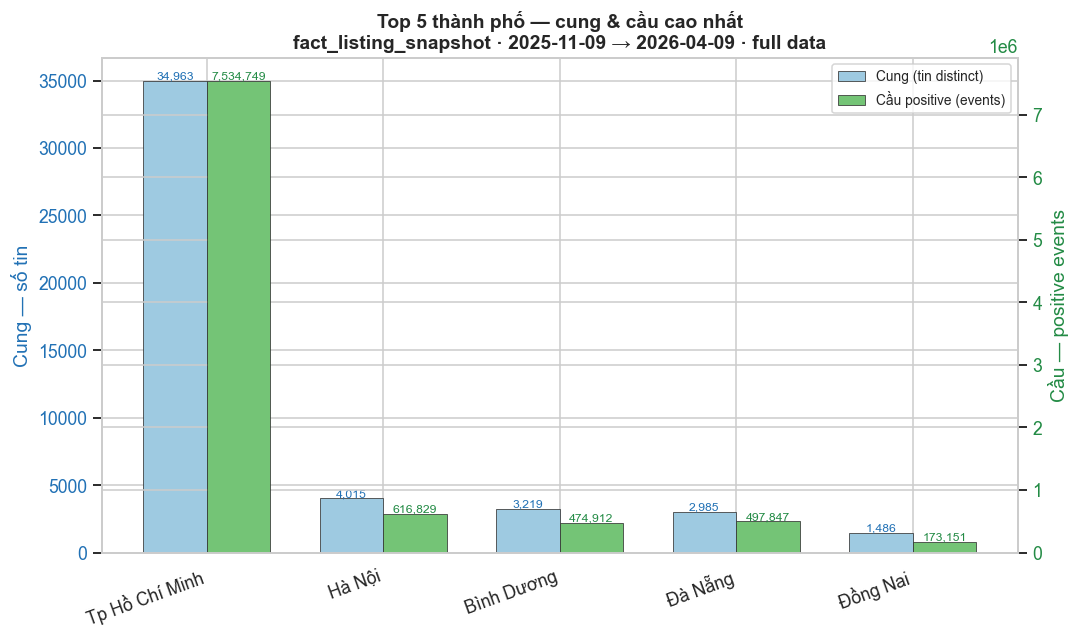

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_supply_demand_cvr/fig_06_top5_cities_supply_demand.png


,city_name,n_listings,n_positive_events,rank_score
0,Tp Hồ Chí Minh,34963,7534749,42497.749
1,Hà Nội,4015,616829,4631.829
2,Bình Dương,3219,474912,3693.912
3,Đà Nẵng,2985,497847,3482.847
4,Đồng Nai,1486,173151,1659.151


In [ ]:
top_city = con.execute(f"""
WITH {sql_snap_dim()},
supply_city AS (
    SELECT
        d.city_name,
        COUNT(DISTINCT s.item_id)::BIGINT AS n_listings
    FROM snap_enriched s
    INNER JOIN dim_snap d ON s.item_id = d.item_id
    GROUP BY 1
),
demand_city AS (
    SELECT
        d.city_name,
        SUM(CASE WHEN e.event_type IN ({POSITIVE_SQL}) THEN 1 ELSE 0 END)::BIGINT
            AS n_positive_events
    FROM read_parquet('{snap.EVENTS_GLOB}') e
    INNER JOIN dim_snap d ON CAST(e.item_id AS VARCHAR) = d.item_id
    CROSS JOIN snap_window w
    WHERE e.date BETWEEN w.eda_min AND w.eda_max
    GROUP BY 1
)
SELECT
    s.city_name,
    s.n_listings,
    COALESCE(d.n_positive_events, 0)::BIGINT AS n_positive_events,
    (s.n_listings + COALESCE(d.n_positive_events, 0) / 1000.0) AS rank_score
FROM supply_city s
LEFT JOIN demand_city d ON s.city_name = d.city_name
ORDER BY rank_score DESC
LIMIT 5
""").df()

top_city.to_csv(OUT_DIR / "03_top5_cities_supply_demand.csv", index=False)
print("Saved", OUT_DIR / "03_top5_cities_supply_demand.csv")

plot_df = top_city.copy()
plot_df["idx_supply"] = 100.0 * plot_df["n_listings"] / plot_df["n_listings"].max()
plot_df["idx_demand"] = 100.0 * plot_df["n_positive_events"] / plot_df["n_positive_events"].max()

cities = plot_df["city_name"].astype(str).tolist()
x = np.arange(len(plot_df))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True)

for ax, col, idx_col, color, title, fmt in [
    (axes[0], "n_listings", "idx_supply", "#9ecae1", "Cung (tin)", "{:,.0f}"),
    (axes[1], "n_positive_events", "idx_demand", "#74c476", "Cầu positive", "{:,.0f}"),
]:
    bars = ax.bar(x, plot_df[idx_col], width=0.55, color=color, edgecolor="#333", linewidth=0.5)
    ax.set_ylabel("Chỉ số (=100 tại city lớn nhất trong top 5)")
    ax.set_ylim(0, 108)
    ax.set_title(title, fontweight="bold")
    ax.grid(axis="y", alpha=0.35)
    for b, v, raw in zip(bars, plot_df[idx_col], plot_df[col]):
        ax.text(
            b.get_x() + b.get_width() / 2,
            b.get_height() + 1.5,
            fmt.format(raw),
            ha="center",
            va="bottom",
            fontsize=8,
        )

axes[0].set_xticks(x)
axes[0].set_xticklabels(cities, rotation=22, ha="right")
axes[1].set_xticklabels([])

fig.suptitle(
    "Top 5 thành phố — cung & cầu (chuẩn hóa để so sánh)\n" + snap.DATA_RANGE,
    fontweight="bold",
    y=1.02,
)
fig.text(
    0.5,
    0.01,
    "Hai panel cùng thang 0–100 · số trên cột = giá trị thực",
    ha="center",
    fontsize=9,
    color="#555",
)
show_and_save("fig_06_top5_cities_supply_demand.png", dpi=130)
display(top_city)

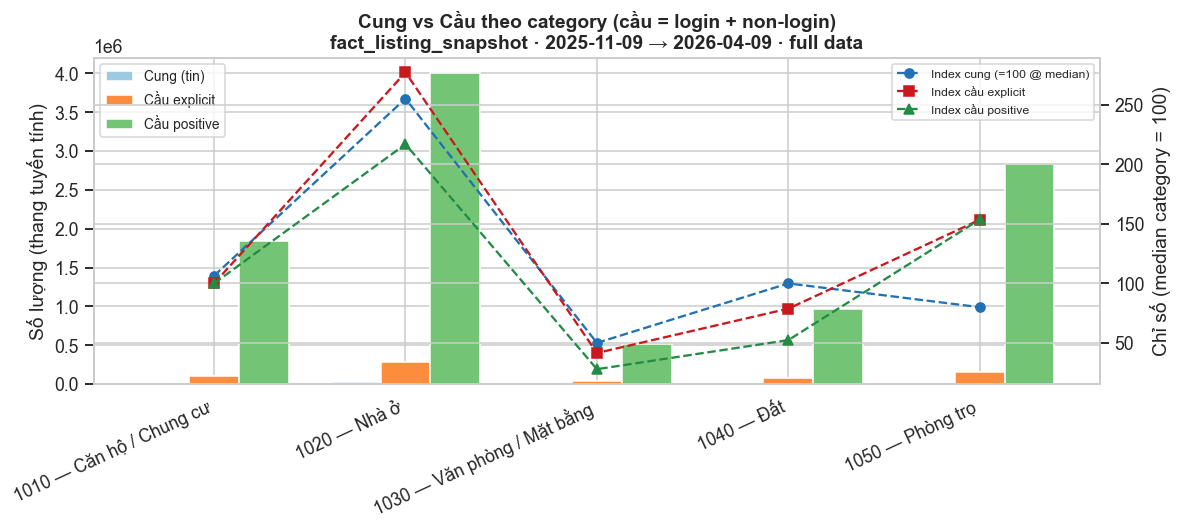

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_supply_demand_cvr/fig_01_supply_vs_demand_bars.png


In [ ]:
labels = df["category_label"].astype(str).tolist()
x = np.arange(len(df))
w = 0.26

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(x - w, df["n_listings"], width=w, label="Cung (tin)", color="#9ecae1")
ax1.bar(x, df["n_explicit_events"], width=w, label="Cầu explicit", color="#fd8d3c")
ax1.bar(x + w, df["n_positive_events"], width=w, label="Cầu positive", color="#74c476")
ax1.set_ylabel("Số lượng (thang tuyến tính)")
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=25, ha="right")
ax1.set_title(
    "Cung vs Cầu theo category (cầu = login + non-login)\n" + snap.DATA_RANGE,
    fontweight="bold",
)
ax1.legend(loc="upper left", fontsize=9)

ax2 = ax1.twinx()
idx_base = df["n_listings"] / df["n_listings"].median() * 100
idx_exp = df["n_explicit_events"] / df["n_explicit_events"].median() * 100
idx_pos = df["n_positive_events"] / df["n_positive_events"].median() * 100
ax2.plot(x, idx_base, "o--", color="#2171b5", label="Index cung (=100 @ median)")
ax2.plot(x, idx_exp, "s--", color="#cb181d", label="Index cầu explicit")
ax2.plot(x, idx_pos, "^--", color="#238b45", label="Index cầu positive")
ax2.set_ylabel("Chỉ số (median category = 100)")
ax2.legend(loc="upper right", fontsize=8)
show_and_save("fig_01_supply_vs_demand_bars.png", dpi=130)

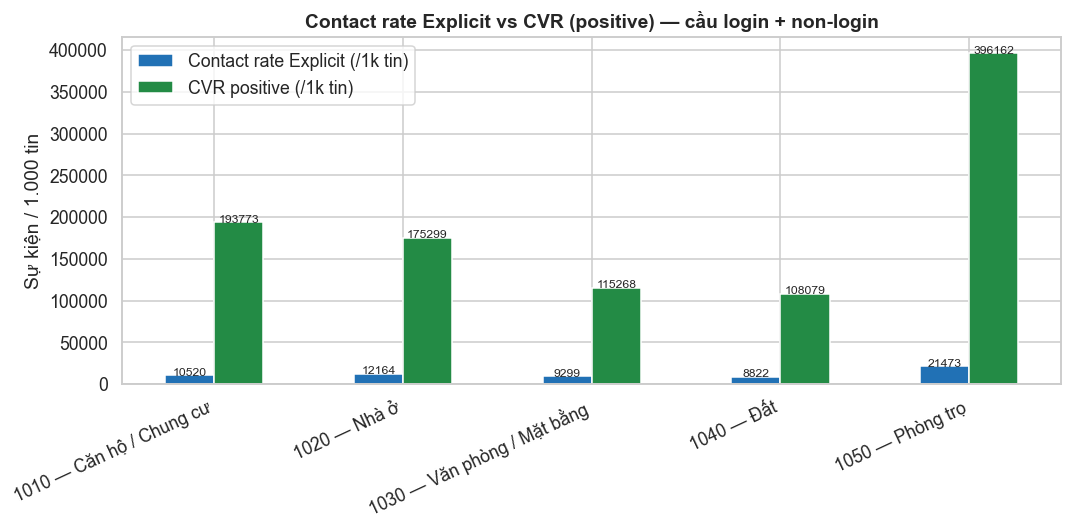

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_supply_demand_cvr/fig_02_explicit_vs_positive_cvr.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w / 2, df["explicit_per_1k_listings"], width=w,
       label="Contact rate Explicit (/1k tin)", color="#2171b5")
ax.bar(x + w / 2, df["positive_per_1k_listings"], width=w,
       label="CVR positive (/1k tin)", color="#238b45")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("Sự kiện / 1.000 tin")
ax.set_title(
    "Contact rate Explicit vs CVR (positive) — cầu login + non-login",
    fontweight="bold",
)
ax.legend()
for i, row in df.iterrows():
    ax.text(i - w / 2, row["explicit_per_1k_listings"] + 2,
            f"{row['explicit_per_1k_listings']:.0f}", ha="center", fontsize=8)
    ax.text(i + w / 2, row["positive_per_1k_listings"] + 2,
            f"{row['positive_per_1k_listings']:.0f}", ha="center", fontsize=8)
show_and_save("fig_02_explicit_vs_positive_cvr.png", dpi=130)

/var/folders/gl/t2pfk0nn6r11bnblrgzwmq8m0000gn/T/ipykernel_10690/3102625683.py:89: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/gl/t2pfk0nn6r11bnblrgzwmq8m0000gn/T/ipykernel_10690/3102625683.py:90: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.savefig(path, bbox_inches="tight", **kwargs)
/Users/dothinh_3112/Downloads/Datathon_Data/env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


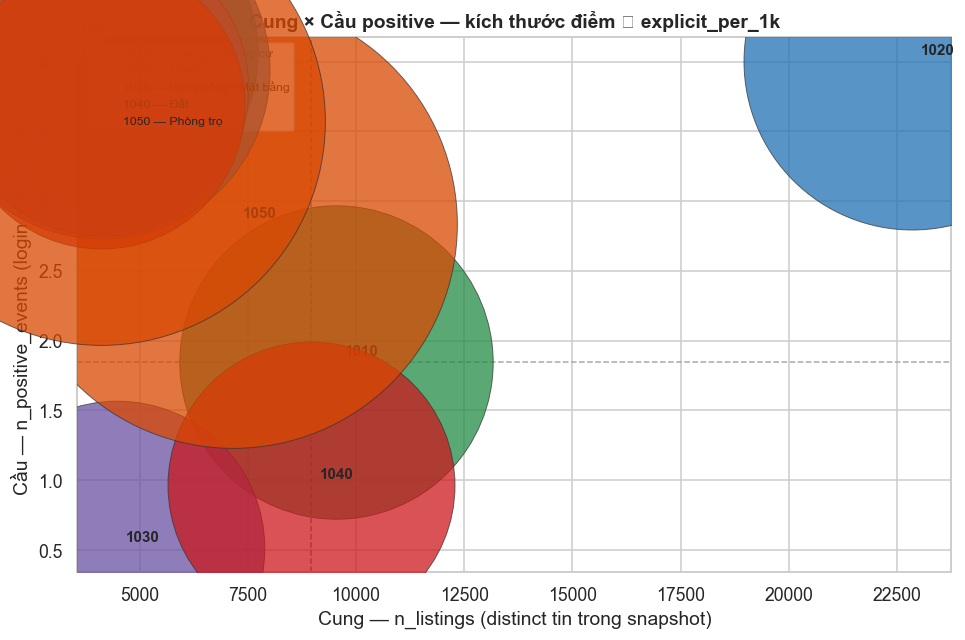

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_supply_demand_cvr/fig_03_scatter_supply_demand.png


In [ ]:
med_x = float(df["n_listings"].median())
med_y = float(df["n_positive_events"].median())

fig, ax = plt.subplots(figsize=(9, 6))
for _, row in df.iterrows():
    c = int(row["category"])
    size = max(40.0, float(row["explicit_per_1k_listings"]) * 4)
    ax.scatter(row["n_listings"], row["n_positive_events"],
               s=size, color=snap.PALETTE[c], label=snap.CAT_META[c],
               alpha=0.75, edgecolors="#333", linewidths=0.6, zorder=3)
    ax.annotate(str(c), (row["n_listings"], row["n_positive_events"]),
                textcoords="offset points", xytext=(6, 4), fontsize=10, fontweight="bold")
ax.axvline(med_x, color="#888", ls="--", lw=1, label=f"Median cung ({med_x:,.0f})")
ax.axhline(med_y, color="#aaa", ls="--", lw=1, label=f"Median cầu positive ({med_y:,.0f})")
ax.set_xlabel("Cung — n_listings (distinct tin trong snapshot)")
ax.set_ylabel("Cầu — n_positive_events (login + non-login)")
ax.set_title("Cung × Cầu positive — kích thước điểm ∝ explicit_per_1k", fontweight="bold")
handles, labels_leg = ax.get_legend_handles_labels()
ax.legend(handles[:5], labels_leg[:5], loc="upper left", fontsize=8)
show_and_save("fig_03_scatter_supply_demand.png", dpi=130)

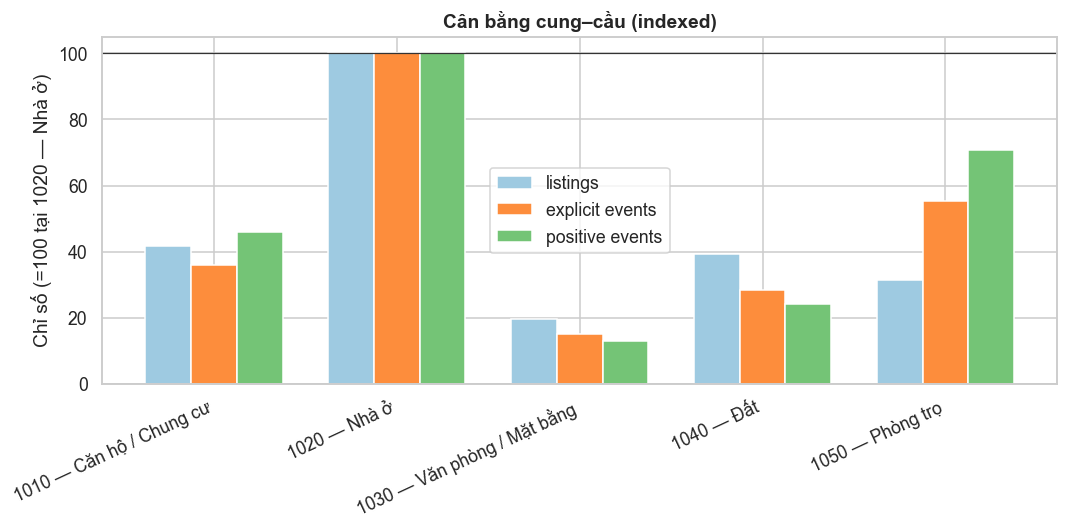

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_supply_demand_cvr/fig_04_indexed_balance.png


In [ ]:
ref = df.loc[df["category"] == 1020].iloc[0]
metrics = ["n_listings", "n_explicit_events", "n_positive_events"]
idx = df.copy()
for m in metrics:
    idx[f"idx_{m}"] = 100.0 * df[m] / ref[m] if ref[m] else np.nan

fig, ax = plt.subplots(figsize=(10, 5))
bw = 0.25
for j, m in enumerate(metrics):
    ax.bar(x + (j - 1) * bw, idx[f"idx_{m}"], width=bw,
           label=m.replace("n_", "").replace("_", " "),
           color=["#9ecae1", "#fd8d3c", "#74c476"][j])
ax.axhline(100, color="#333", ls="-", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("Chỉ số (=100 tại 1020 — Nhà ở)")
ax.set_title("Cân bằng cung–cầu (indexed)", fontweight="bold")
ax.legend()
show_and_save("fig_04_indexed_balance.png", dpi=130)

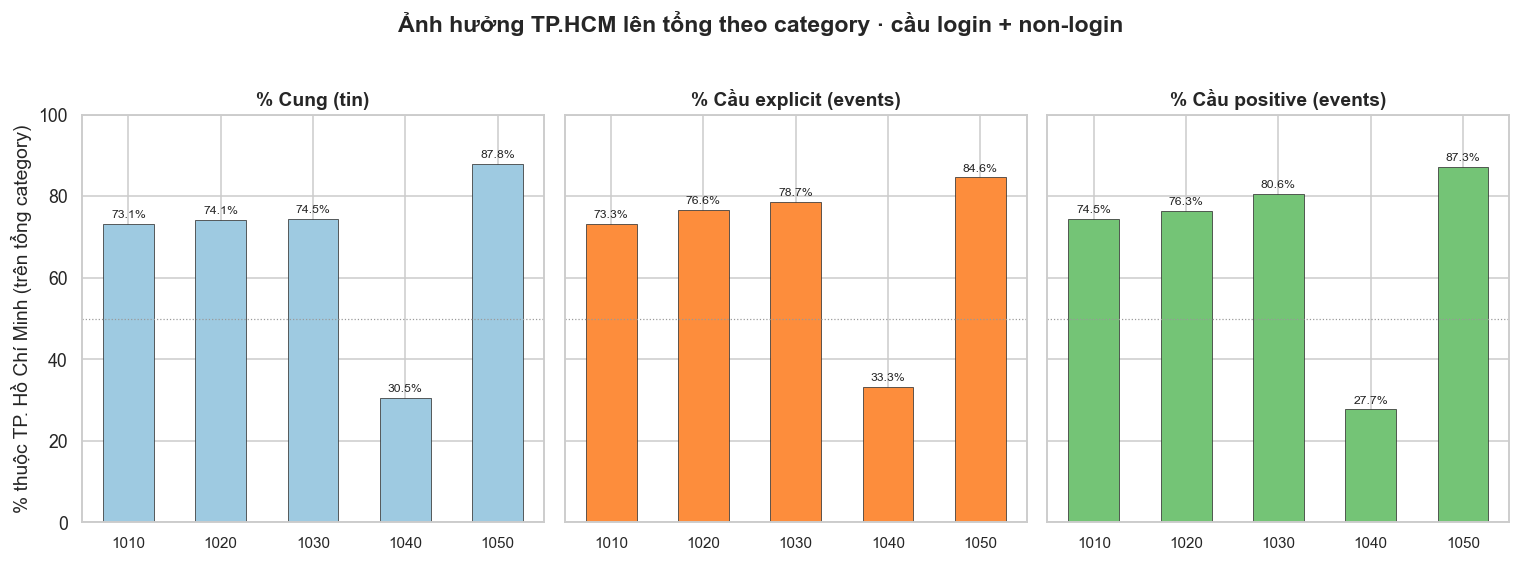

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_supply_demand_cvr/fig_05_hcm_influence_by_category.png


In [ ]:
x_h = np.arange(len(df_hcm))
labels_h = df_hcm["category_label"].astype(str).tolist()
w3 = 0.24
metrics_hcm = [
    ("pct_supply_hcm", "% Cung (tin)", "#9ecae1"),
    ("pct_explicit_events_hcm", "% Cầu explicit (events)", "#fd8d3c"),
    ("pct_positive_events_hcm", "% Cầu positive (events)", "#74c476"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
for ax, (col, title, color) in zip(axes, metrics_hcm):
    bars = ax.bar(x_h, df_hcm[col], width=0.55, color=color, edgecolor="#333", linewidth=0.5)
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(x_h)
    ax.set_xticklabels([str(c) for c in df_hcm["category"]], fontsize=10)
    ax.set_ylim(0, min(100, max(105, df_hcm[col].max() * 1.15)))
    ax.axhline(50, color="#999", ls=":", lw=0.8)
    for b, v in zip(bars, df_hcm[col]):
        ax.text(
            b.get_x() + b.get_width() / 2,
            b.get_height() + 1,
            f"{v:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8,
        )
axes[0].set_ylabel("% thuộc TP. Hồ Chí Minh (trên tổng category)")
fig.suptitle(
    "Ảnh hưởng TP.HCM lên tổng theo category · cầu login + non-login",
    fontweight="bold",
    y=1.02,
)
show_and_save("fig_05_hcm_influence_by_category.png", dpi=130)

In [ ]:
def _row_max(col):
    i = df[col].idxmax()
    return int(df.loc[i, "category"]), snap.CAT_META[int(df.loc[i, "category"])], float(df.loc[i, col])

c_sup, l_sup, v_sup = _row_max("n_listings")
c_exp, l_exp, v_exp = _row_max("n_explicit_events")
c_pos, l_pos, v_pos = _row_max("positive_per_1k_listings")
c_lo = int(df.loc[df["explicit_per_1k_listings"].idxmin(), "category"])
l_lo = snap.CAT_META[c_lo]
v_lo = float(df.loc[df["explicit_per_1k_listings"].idxmin(), "explicit_per_1k_listings"])

high_cvr_low_supply = df.sort_values(
    ["positive_per_1k_listings", "n_listings"], ascending=[False, True]
).head(2)

exec_path = snap.CROSS_DIR / "executive_ranking.csv"
snap_note = ""
if exec_path.exists():
    er = pd.read_csv(exec_path)
    top_snap = er.loc[er["contact_rate_pct"].idxmax()]
    snap_note = (
        f"- **QA snapshot:** `contact_rate_pct` cao nhất = **{snap.CAT_META[int(top_snap['category'])]}** "
        f"({top_snap['contact_rate_pct']:.2f}% — Σcontacts÷Σviews), khác metric explicit/1k tin.\n"
    )

i_hcm_sup = df_hcm["pct_supply_hcm"].idxmax()
i_hcm_exp = df_hcm["pct_explicit_events_hcm"].idxmax()
r_hcm_sup = df_hcm.loc[i_hcm_sup]
r_hcm_exp = df_hcm.loc[i_hcm_exp]

md = f"""### Tóm tắt

- **Cầu:** login + non-login (không lọc `is_login`).
- **Cung lớn nhất:** {l_sup} — **{v_sup:,.0f}** tin (`n_listings`).
- **Cầu explicit lớn nhất:** {l_exp} — **{v_exp:,.0f}** events.
- **CVR (positive) cao nhất:** {l_pos} — **{v_pos:,.1f}** / 1k tin.
- **Contact rate Explicit thấp nhất:** {l_lo} — **{v_lo:,.1f}** / 1k tin.

### TP. Hồ Chí Minh (% trên tổng category)

- **% cung HCM cao nhất:** {r_hcm_sup['category_label']} — **{r_hcm_sup['pct_supply_hcm']:.1f}%** tin.
- **% cầu explicit HCM cao nhất:** {r_hcm_exp['category_label']} — **{r_hcm_exp['pct_explicit_events_hcm']:.1f}%** events.
- Chart: `fig_05_hcm_influence_by_category.png`, bảng `02_hcm_share_by_category.csv`.

**Cung cao · CVR explicit thấp (oversupply tiềm năng):** category có `n_listings` top nhưng `explicit_per_1k` dưới median ({df['explicit_per_1k_listings'].median():.1f}):
"""
for _, r in df[df["n_listings"] >= df["n_listings"].quantile(0.6)].iterrows():
    if r["explicit_per_1k_listings"] < df["explicit_per_1k_listings"].median():
        md += f"\n  - {snap.CAT_META[int(r['category'])]}: {r['n_listings']:,.0f} tin, explicit/1k = {r['explicit_per_1k_listings']:.1f}"

md += f"\n\n**CVR positive cao · cung tương đối thấp:**\n"
for _, r in high_cvr_low_supply.iterrows():
    md += (
        f"\n  - {snap.CAT_META[int(r['category'])]}: positive/1k = {r['positive_per_1k_listings']:.1f}, "
        f"tin = {r['n_listings']:,.0f}"
    )

md += f"\n\n{snap_note}"
md += (
    "\n**Tổng weighted:** "
    f"explicit/1k = **{total['explicit_per_1k_listings'].iloc[0]:.1f}**, "
    f"positive/1k = **{total['positive_per_1k_listings'].iloc[0]:.1f}**."
)

display(Markdown(md))
(OUT_DIR / "99_insights.md").write_text(md, encoding="utf-8")
print("Saved", OUT_DIR / "99_insights.md")

### Tóm tắt

- **Cầu:** login + non-login (không lọc `is_login`).
- **Cung lớn nhất:** 1020 — Nhà ở — **22,836** tin (`n_listings`).
- **Cầu explicit lớn nhất:** 1020 — Nhà ở — **277,788** events.
- **CVR (positive) cao nhất:** 1050 — Phòng trọ — **396,161.5** / 1k tin.
- **Contact rate Explicit thấp nhất:** 1040 — Đất — **8,822.2** / 1k tin.

### TP. Hồ Chí Minh (% trên tổng category)

- **% cung HCM cao nhất:** 1050 — Phòng trọ — **87.8%** tin.
- **% cầu explicit HCM cao nhất:** 1050 — Phòng trọ — **84.6%** events.
- Chart: `fig_05_hcm_influence_by_category.png`, bảng `02_hcm_share_by_category.csv`.

**Cung cao · CVR explicit thấp (oversupply tiềm năng):** category có `n_listings` top nhưng `explicit_per_1k` dưới median (10519.6):


**CVR positive cao · cung tương đối thấp:**

  - 1050 — Phòng trọ: positive/1k = 396161.5, tin = 7,162
  - 1010 — Căn hộ / Chung cư: positive/1k = 193772.6, tin = 9,527

- **QA snapshot:** `contact_rate_pct` cao nhất = **1040 — Đất** (11.01% — Σcontacts÷Σviews), khác metric explicit/1k tin.

**Tổng weighted:** explicit/1k = **12320.0**, positive/1k = **192051.1**.

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_supply_demand_cvr/99_insights.md
